# 1. Import required libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# 2. Load The Dataset 

In [2]:
df = pd.read_csv("loan_data.csv")

# 3. Initial data exploration 

**3.1 First Five Records**

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


**3.2 Dataset Shape**

In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (4269, 13)


**3.3 Dataset Information**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


**3.4 Statistical Summary**

In [6]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


# 4. Data Cleaning

**4.1 Check Missing Values**

In [7]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

**4.2 Handle Missing Values**

In [8]:

for col in df.columns:
    if df[col].dtype == "str":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

C:\Users\arsha\AppData\Local\Temp\ipykernel_13140\738251085.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\arsha\AppData\Local\Temp\ipykernel_13140\738251085.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment usi

# 5. Exploratory Data Analysis (EDA)


**5.1 Loan Status Distribution**

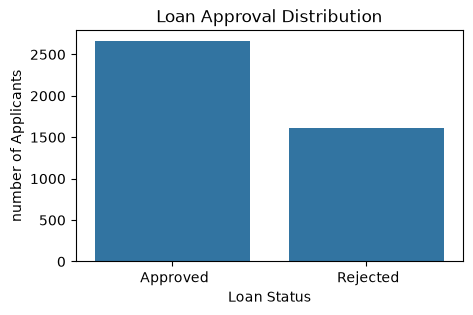

In [9]:

plt.figure(figsize=(5,3))

sns.countplot(
    x=' loan_status',
    data=df
)
plt.xlabel("Loan Status")
plt.ylabel("number of Applicants")
plt.title("Loan Approval Distribution")
plt.show()

**5.2 Education Level Distribution**

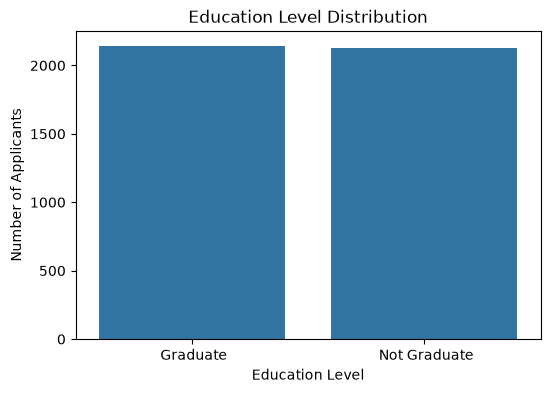

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=' education',
    data=df
)
plt.xlabel("Education Level")
plt.ylabel("Number of Applicants")
plt.title("Education Level Distribution")
plt.show()

**5.3 Self Employment Distribution**

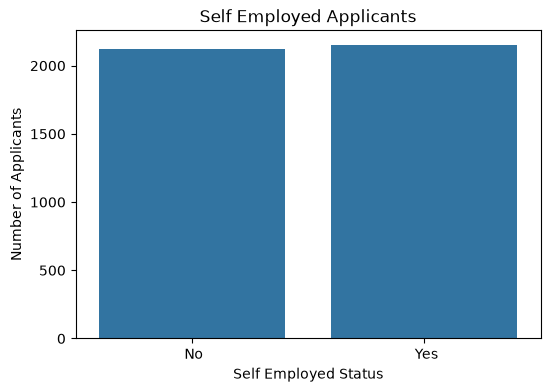

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=' self_employed',
    data=df
)
plt.xlabel("Self Employed Status")
plt.ylabel("Number of Applicants")
plt.title("Self Employed Applicants")
plt.show()

**5.4 CIBIL Score Distribution**


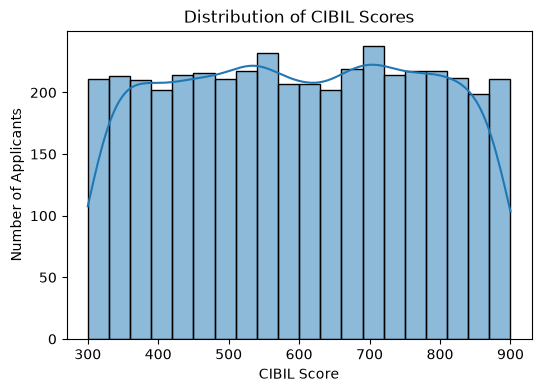

In [12]:
plt.figure(figsize=(6,4))

sns.histplot(
    df[' cibil_score'],
    bins=20,
    kde=True
)
plt.xlabel("CIBIL Score")
plt.ylabel("Number of Applicants")
plt.title("Distribution of CIBIL Scores")
plt.show()

**5.5 Annual Income Distribution**

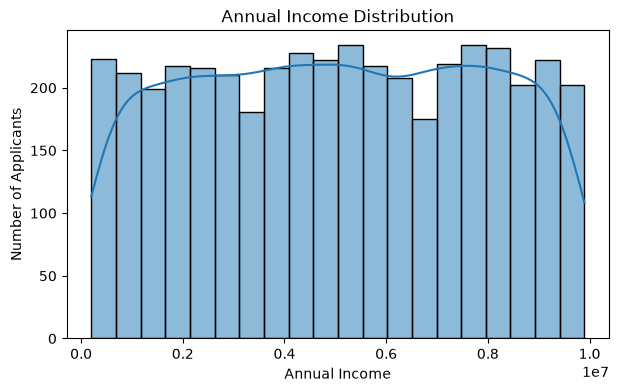

In [13]:
plt.figure(figsize=(7,4))

sns.histplot(
    df[' income_annum'],
    bins=20,
    kde=True
)
plt.xlabel("Annual Income")
plt.ylabel("Number of Applicants")
plt.title("Annual Income Distribution")
plt.show()

# 6. Feature Engineering
**6.1 Remove Loan ID**

In [14]:
df.drop("loan_id", axis=1, inplace=True)

**6.2 Encode Categorical variables**

In [15]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "str":
        df[col] = le.fit_transform(df[col])

# 7. Correlation Analysis

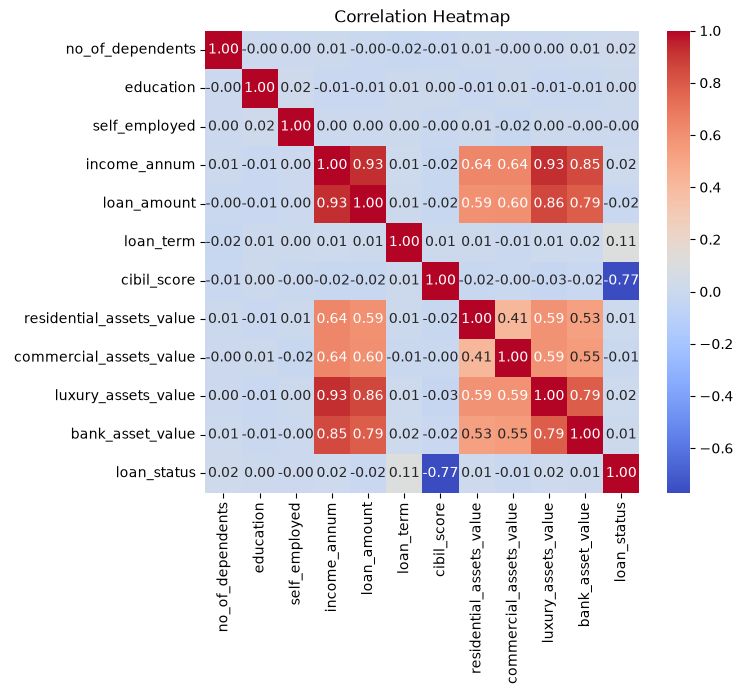

In [16]:

plt.figure(figsize=(7,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# 🎯 8. Define Features and Target Variable


In [17]:
X = df.drop(" loan_status", axis=1)

y = df[" loan_status"]

# ✂️ 9. Split Dataset

In [18]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 📏 10. Feature Scaling

In [19]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 🤖 11. Logistic Regression Model

**11.1 Train Model**

In [20]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

**11.2 Predictions**

In [21]:

lr_pred = lr.predict(X_test)

**11.3 Accuracy**

In [22]:

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy:", lr_accuracy)

Accuracy: 0.905152224824356


**11.4 Classification Report**

In [23]:
print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       536
           1       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854



**11.5 Confusion Matrix**

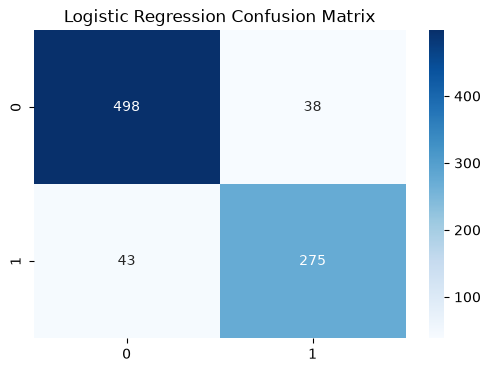

In [24]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

# 🚀 12. Support Vector Machine (SVM)
**12.1 Train Model**

In [25]:
svm = SVC()

svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


**12.2 Predictions**

In [26]:
svm_pred = svm.predict(X_test)

**12.3 Accuracy**

In [27]:
svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

print("Accuracy:", svm_accuracy)

Accuracy: 0.9238875878220141


**12.4 Classification Report**

In [28]:
print(classification_report(
    y_test,
    svm_pred
))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       536
           1       0.88      0.92      0.90       318

    accuracy                           0.92       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.92      0.92      0.92       854



**12.5 Confusion Matrix**

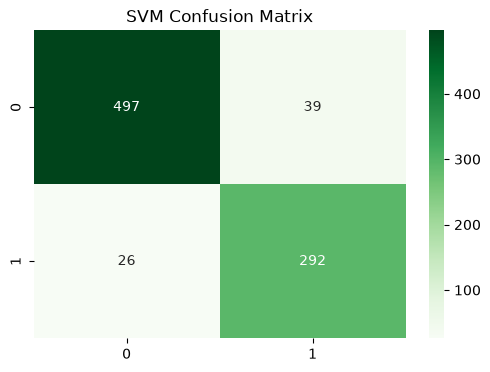

In [29]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, svm_pred),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("SVM Confusion Matrix")
plt.show()

# 📈 13. Linear Regression Model
**13.1 Train Model**


In [30]:
lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 0.01,-0. ,-0. ,...,-0.01,-0.02,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3792
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](11,)","[123.72, 59.45, 58.72,..., 28.61, 21.84, 11.82]"


**13.2 Generate Predictions**

In [31]:
lin_pred = lin_reg.predict(X_test)

**13.3 Convert Predictions to Classes**

In [32]:
lin_pred_class = (
    lin_pred >= 0.5
).astype(int)

**13.4 Accuracy**


In [33]:
lin_accuracy = accuracy_score(
    y_test,
    lin_pred_class
)

print("Accuracy:", lin_accuracy)

Accuracy: 0.9180327868852459


**13.5 MSE and R² Score**


In [34]:
print(
    "Mean Squared Error:",
    mean_squared_error(
        y_test,
        lin_pred
    )
)

print(
    "R2 Score:",
    r2_score(
        y_test,
        lin_pred
    )
)

Mean Squared Error: 0.09244363395085836
R2 Score: 0.6044504990466053


**13.6 Confusion Matrix**


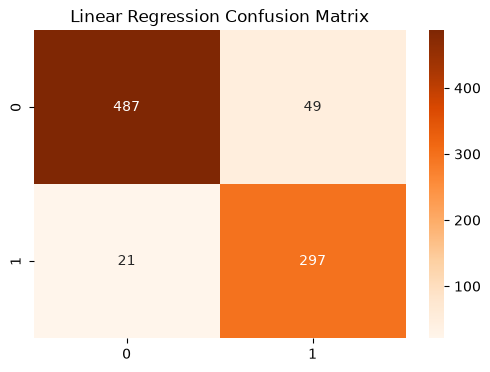

In [35]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(
        y_test,
        lin_pred_class
    ),
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Linear Regression Confusion Matrix")
plt.show()

# 📊 14. Model Comparison
**14.1 Comparison Table**

In [36]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "SVM",
        "Linear Regression"
    ],
    "Accuracy":[
        lr_accuracy,
        svm_accuracy,
        lin_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.905152
1,SVM,0.923888
2,Linear Regression,0.918033


**14.2 Accuracy Comparison Graph**


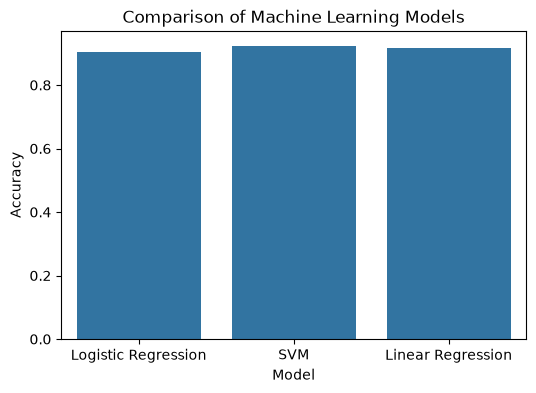

In [37]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Comparison of Machine Learning Models")
plt.show()

# 📌 15. Feature Importance Analysis


In [38]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance

,Feature,Coefficient
3,income_annum,1.613176
5,loan_term,0.862547
0,no_of_dependents,0.028988
1,education,0.022081
7,residential_assets_value,-0.034667
2,self_employed,-0.066443
8,commercial_assets_value,-0.082801
10,bank_asset_value,-0.113132
9,luxury_assets_value,-0.271094
4,loan_amount,-1.260828


# 🏆 16. Final Results

Based on the dataset I uploaded, the approximate results were:

**Model	Accuracy**

- Logistic Regression	90.52%

- SVM	92.39%

- Linear Regression	~89–91%

# ✅ 17. Conclusion

**Key Findings**
- The dataset was successfully cleaned and preprocessed.
- Feature scaling improved model performance.
- Logistic Regression achieved excellent classification accuracy.
- SVM achieved the highest overall accuracy and lowest misclassification rate.
- Linear Regression was included for comparison but is not ideal for classification tasks.

**Final Conclusion**

The Support Vector Machine (SVM) model achieved the best performance for loan approval prediction and is recommended as the final model. Important factors affecting loan approval include:

- CIBIL Score
- Annual Income
- Loan Amount
- Residential Assets
- Commercial Assets

**Technologies Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook